In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization Settings
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv(
    "../outputs/feature_engineered_retail.csv",
    parse_dates=["InvoiceDate"]
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Quarter,DayOfWeek,InvoiceMonthYear,IsWeekend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,4,Wednesday,2010-12,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,4,Wednesday,2010-12,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,4,Wednesday,2010-12,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,4,Wednesday,2010-12,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,4,Wednesday,2010-12,False


In [4]:
df.shape

(392692, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         392692 non-null  int64         
 1   StockCode         392692 non-null  str           
 2   Description       392692 non-null  str           
 3   Quantity          392692 non-null  int64         
 4   InvoiceDate       392692 non-null  datetime64[us]
 5   UnitPrice         392692 non-null  float64       
 6   CustomerID        392692 non-null  float64       
 7   Country           392692 non-null  str           
 8   Revenue           392692 non-null  float64       
 9   Year              392692 non-null  int64         
 10  Month             392692 non-null  int64         
 11  MonthName         392692 non-null  str           
 12  Quarter           392692 non-null  int64         
 13  DayOfWeek         392692 non-null  str           
 14  InvoiceMonthYea

In [6]:
reference_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm = (
    df.groupby("CustomerID")
      .agg({
          "InvoiceDate": lambda x:
              (reference_date - x.max()).days,
          "InvoiceNo": "nunique",
          "Revenue": "sum"
      })
      .reset_index()
)

rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [7]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


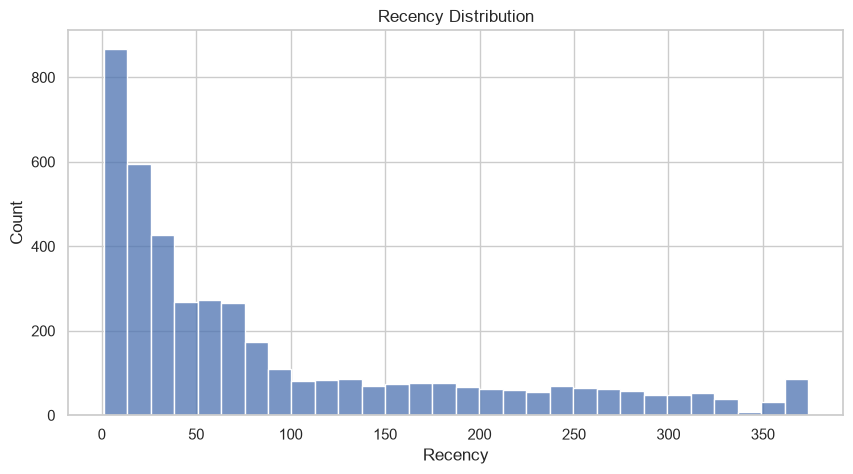

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    rfm["Recency"],
    bins=30
)

plt.title("Recency Distribution")

plt.show()

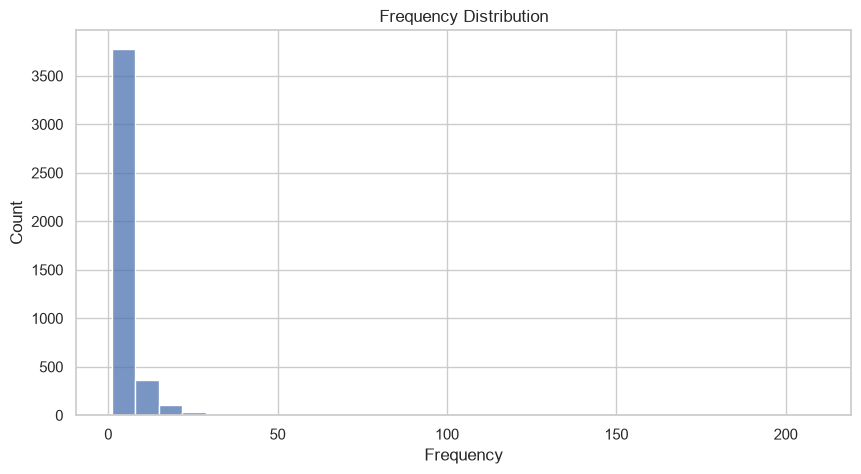

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    rfm["Frequency"],
    bins=30
)

plt.title("Frequency Distribution")

plt.show()

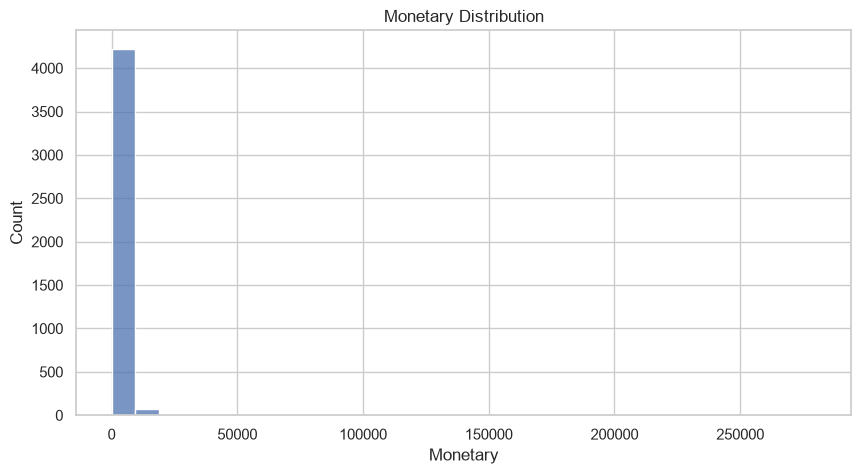

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    rfm["Monetary"],
    bins=30
)

plt.title("Monetary Distribution")

plt.show()

In [11]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [12]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

def segment_customer(row):

    if (
        row["R_Score"] >= 4 and
        row["F_Score"] >= 4 and
        row["M_Score"] >= 4
    ):
        return "Champions"

    elif (
        row["R_Score"] >= 3 and
        row["F_Score"] >= 4
    ):
        return "Loyal Customers"

    elif (
        row["R_Score"] >= 4 and
        row["F_Score"] <= 3
    ):
        return "Potential Loyalists"

    elif (
        row["R_Score"] <= 2
    ):
        return "At Risk Customers"

    else:
        return "Regular Customers"

rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [13]:
segment_counts = (
    rfm["Segment"]
      .value_counts()
      .reset_index()
)

segment_counts

,Segment,count
0,At Risk Customers,1708
1,Champions,957
2,Potential Loyalists,633
3,Regular Customers,537
4,Loyal Customers,503


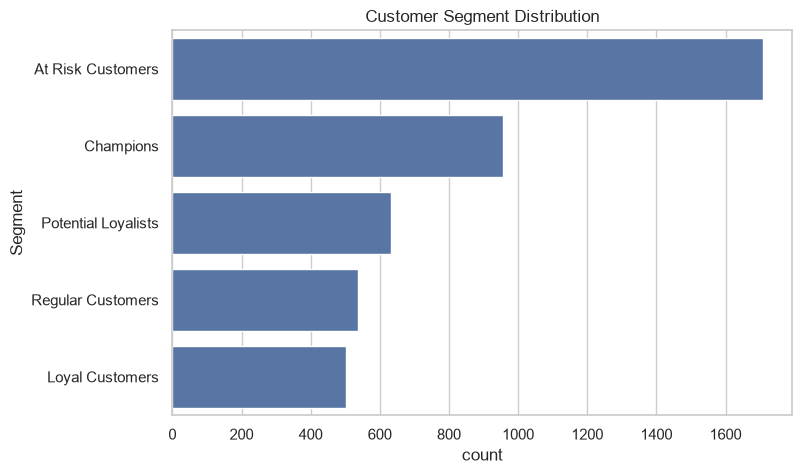

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_counts,
    x="count",
    y="Segment"
)

plt.title("Customer Segment Distribution")

plt.show()

In [15]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

segment_revenue

,Segment,Monetary
0,Champions,5791640.740
1,At Risk Customers,1316374.663
2,Loyal Customers,895651.561
3,Potential Loyalists,557965.270
4,Regular Customers,325576.660


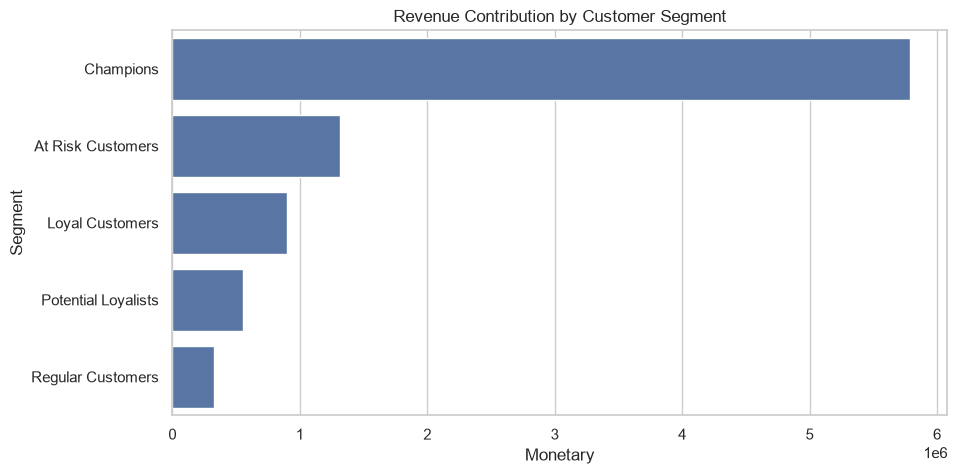

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=segment_revenue,
    x="Monetary",
    y="Segment"
)

plt.title("Revenue Contribution by Customer Segment")

plt.show()

In [17]:
rfm.to_csv(
    "../outputs/customer_rfm.csv",
    index=False
)

print("RFM Dataset Saved Successfully")

RFM Dataset Saved Successfully
